In [2]:
from qdrant_client import QdrantClient
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

In [3]:
client = QdrantClient(host="localhost", port=6333)

points, _ = client.scroll(
    collection_name="unila_docs",
    with_payload=["filename"],
    limit=10000
)

print(f"Total chunk: {len(points)}")

counts = Counter(p.payload["filename"] for p in points)
for name, count in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {count:4d}  {name}")

Total chunk: 1090
   332  Panduan-Penulisan-Karya-Ilmiah-2020.pdf
   222  Peraturan-Akademik-Nomor-12-Tahun-2025.md
   206  SOP-BAK-UNILA.md
    67  PANDUAN-SIAKAD-MAHASISWA.pdf
    46  Keputusan-Rektor-No-359-Tata-Pergaulan-Warga.md
    45  SK-355-Keringanan-Pembebasan-Sanksi-UKT.md
    42  kkn_unila.ac.pdf
    38  Peraturan-Rektor-No-1-Tahun-2024-Seleksi-Mandiri.md
    36  Peraturan-Rektor-No-23-Tahun-2020-UKT-IPI.md
    31  SK-2661-Tarif-UKT-2025-2026.md
    25  SK-2662-Tarif-IPI-2025-2026.md


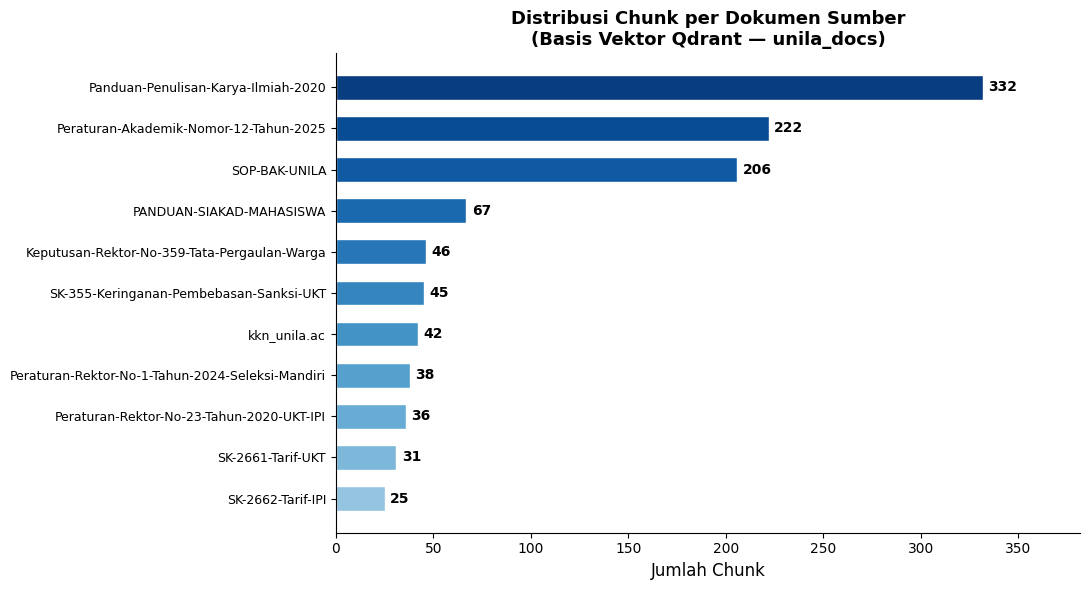

Saved: chunk_distribution.png


In [4]:
# Sort by count descending
sorted_counts = sorted(counts.items(), key=lambda x: x[1])

labels = [k for k, _ in sorted_counts]
values = [v for _, v in sorted_counts]

# Shorten labels for display
short_labels = (
    [l.replace("-2025-2026", "").replace(".md", "").replace(".pdf", "") for l in labels]
)

fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.Blues([0.4 + 0.6 * (i / len(values)) for i in range(len(values))])
bars = ax.barh(short_labels, values, color=colors, edgecolor="white", height=0.6)
ax.bar_label(bars, padding=4, fontsize=10, fontweight="bold")

ax.set_xlabel("Jumlah Chunk", fontsize=12)
ax.set_title("Distribusi Chunk per Dokumen Sumber\n(Basis Vektor Qdrant — unila_docs)", fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, max(values) * 1.15)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig("chunk_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chunk_distribution.png")